<h1>Импорт библиотек

In [50]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [51]:
def sum_prod(X, V):
    '''
    X - список матриц (n, n)
    V - список векторов (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    if len(X) != len(V):
        raise ValueError("Lengths of X and V must match")

    result = None

    for A, v in zip(X, V):
        A = np.array(A)
        v = np.array(v)

        prod = A @ v

        if result is None:
            result = prod
        else:
            result = result + prod

    return result

In [52]:
def test_sum_prod_basic():
    X = [np.eye(2), np.eye(2)]
    V = [np.array([[1], [2]]), np.array([[3], [4]])]

    res = sum_prod(X, V)
    expected = np.array([[4], [6]])

    assert np.allclose(res, expected)


def test_sum_prod_single():
    X = [np.array([[2, 0], [0, 2]])]
    V = [np.array([[1], [1]])]

    res = sum_prod(X, V)
    expected = np.array([[2], [2]])

    assert np.allclose(res, expected)

<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [53]:
def binarize(M, threshold=0.5):
    M = np.array(M)
    return (M > threshold).astype(int)

In [54]:
def test_binarize_basic():
    M = np.array([[0.2, 0.6], [0.5, 0.7]])
    res = binarize(M, threshold=0.5)

    expected = np.array([[0, 1], [0, 1]])
    assert np.array_equal(res, expected)


def test_binarize_all_zero():
    M = np.zeros((2, 2))
    res = binarize(M)

    assert np.array_equal(res, np.zeros((2, 2)))

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [55]:
def unique_rows(mat):
    mat = np.array(mat)
    return [np.unique(row) for row in mat]


def unique_columns(mat):
    mat = np.array(mat)
    return [np.unique(mat[:, i]) for i in range(mat.shape[1])]

In [56]:
def test_unique_rows():
    mat = np.array([[1, 2, 2], [3, 3, 4]])
    res = unique_rows(mat)

    assert np.array_equal(res[0], np.array([1, 2]))
    assert np.array_equal(res[1], np.array([3, 4]))


def test_unique_columns():
    mat = np.array([[1, 2], [1, 3], [2, 3]])
    res = unique_columns(mat)

    assert np.array_equal(res[0], np.array([1, 2]))
    assert np.array_equal(res[1], np.array([2, 3]))

<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

[ 0.22526898 -0.10986516  0.77908662  0.39696212]
[1.33909354 1.51079446 0.85018252 1.16693204 1.23104208]


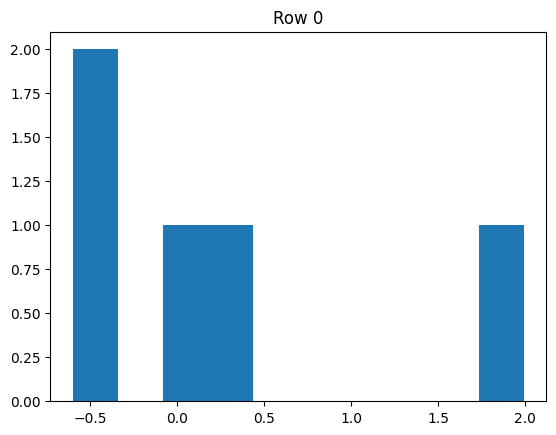

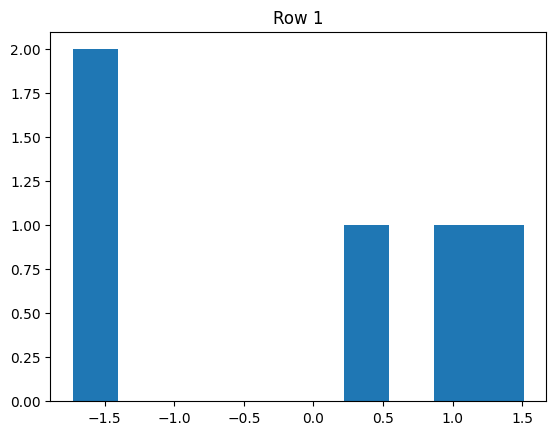

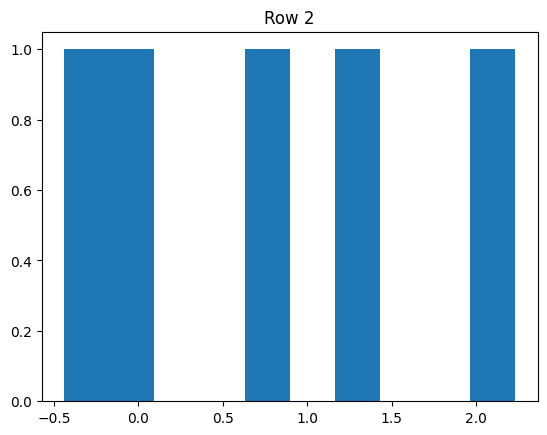

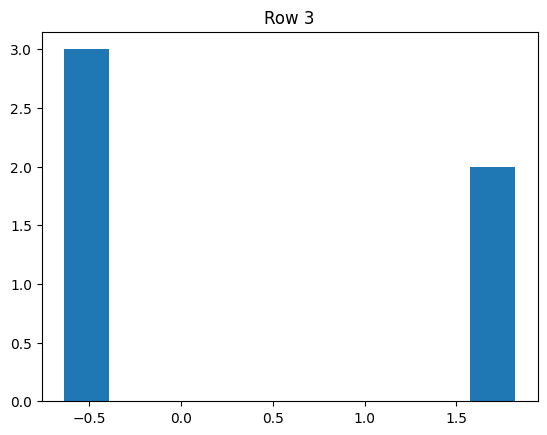

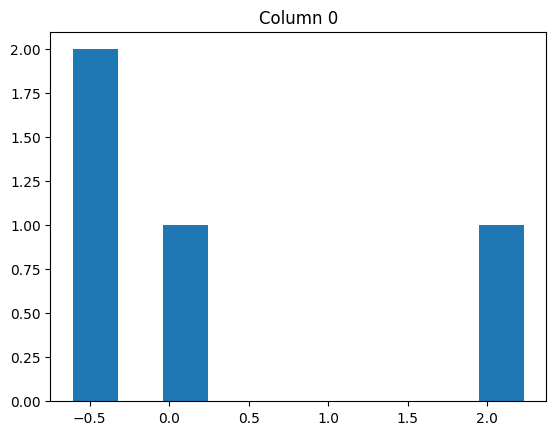

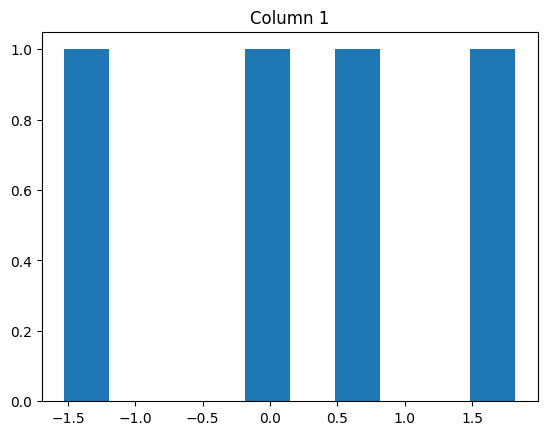

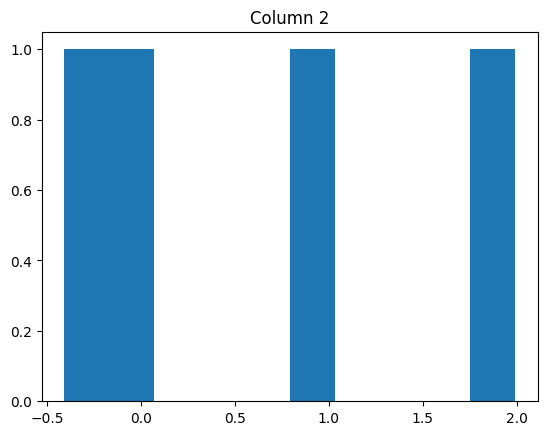

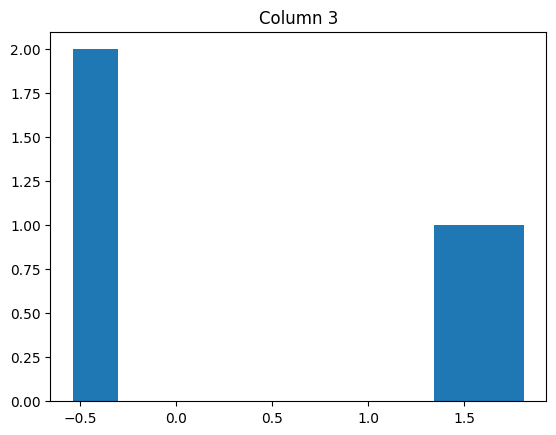

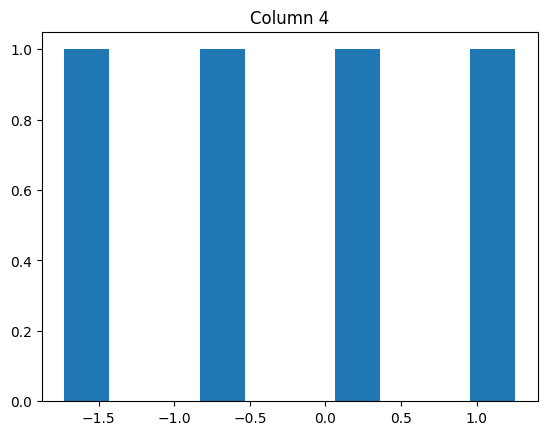

In [57]:
def analyze_matrix(m, n):
    M = np.random.randn(m, n)

    return {
        "matrix": M,
        "row_means": np.mean(M, axis=1),
        "row_vars": np.var(M, axis=1),
        "col_means": np.mean(M, axis=0),
        "col_vars": np.var(M, axis=0)
    }

def plot_matrix_stats(M):
    m, n = M.shape

    # строки
    for i in range(m):
        plt.figure()
        plt.hist(M[i, :], bins=10)
        plt.title(f"Row {i}")

    # столбцы
    for j in range(n):
        plt.figure()
        plt.hist(M[:, j], bins=10)
        plt.title(f"Column {j}")

    plt.show()

res = analyze_matrix(4, 5)

print(res["row_means"])
print(res["col_vars"])

plot_matrix_stats(res["matrix"])

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [58]:
def chess(m, n, a, b):
    M = np.zeros((m, n))

    for i in range(m):
        for j in range(n):
            if (i + j) % 2 == 0:
                M[i, j] = a
            else:
                M[i, j] = b

    return M

In [59]:
def test_chess_even():
    res = chess(2, 2, 1, 0)
    expected = np.array([[1, 0],
                         [0, 1]])

    assert np.array_equal(res, expected)


def test_chess_rectangular():
    res = chess(2, 3, 5, 9)
    expected = np.array([[5, 9, 5],
                         [9, 5, 9]])

    assert np.array_equal(res, expected)

<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [60]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    """
    a, b — размеры прямоугольника
    m, n — размеры изображения
    rectangle_color, background_color — (R, G, B)
    """

    img = np.zeros((m, n, 3), dtype=np.uint8)
    img[:] = background_color

    # центр изображения
    cx, cy = m // 2, n // 2

    # границы прямоугольника
    x1 = cx - a // 2
    x2 = cx + a // 2
    y1 = cy - b // 2
    y2 = cy + b // 2

    # обрезка по границам изображения
    x1, x2 = max(0, x1), min(m, x2)
    y1, y2 = max(0, y1), min(n, y2)

    img[x1:x2, y1:y2] = rectangle_color

    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.zeros((m, n, 3), dtype=np.uint8)
    img[:] = background_color

    cx, cy = m // 2, n // 2

    for i in range(m):
        for j in range(n):
            if ((i - cx) ** 2) / (a ** 2) + ((j - cy) ** 2) / (b ** 2) <= 1:
                img[i, j] = ellipse_color

    return img


def show_image(img, title=None):
    plt.figure()
    plt.imshow(img)
    plt.axis('off')  # убираем оси
    if title:
        plt.title(title)
    plt.show()
    

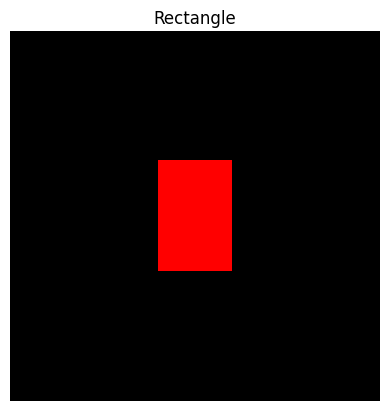

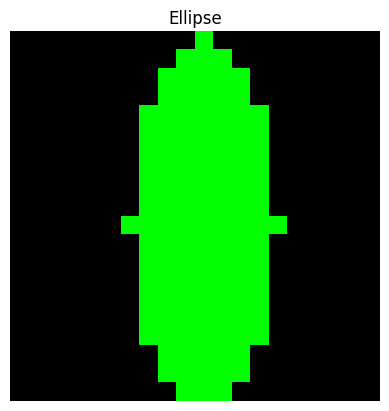

In [61]:
img_rect = draw_rectangle(
    a=6, b=4,
    m=20, n=20,
    rectangle_color=(255, 0, 0),      
    background_color=(0, 0, 0)        
)

show_image(img_rect, "Rectangle")

img_ellipse = draw_ellipse(
    a=10, b=4,
    m=20, n=20,
    ellipse_color=(0, 255, 0),        
    background_color=(0, 0, 0)
)

show_image(img_ellipse, "Ellipse")

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [62]:
def analyze_time_series(ts, p):
    ts = np.array(ts)

    if ts.ndim != 1:
        raise ValueError("Time series must be 1D")

    if p <= 0 or p > len(ts):
        raise ValueError("Invalid window size")

    # базовые статистики
    mean = np.mean(ts)
    var = np.var(ts)
    std = np.std(ts)

    # локальные экстремумы
    local_max = []
    local_min = []

    for i in range(1, len(ts) - 1):
        if ts[i] > ts[i - 1] and ts[i] > ts[i + 1]:
            local_max.append(i)

        if ts[i] < ts[i - 1] and ts[i] < ts[i + 1]:
            local_min.append(i)

    # скользящее среднее
    moving_avg = np.array([
        np.mean(ts[i:i + p]) for i in range(len(ts) - p + 1)
    ])

    return {
        "mean": mean,
        "var": var,
        "std": std,
        "local_max_indices": local_max,
        "local_min_indices": local_min,
        "moving_avg": moving_avg
    }

In [63]:
def test_basic_stats():
    ts = [1, 2, 3, 4]

    res = analyze_time_series(ts, p=2)

    assert res["mean"] == 2.5
    assert res["var"] == 1.25
    assert np.isclose(res["std"], np.sqrt(1.25))


def test_local_extrema():
    ts = [1, 3, 2, 4, 3]

    res = analyze_time_series(ts, p=2)

    assert res["local_max_indices"] == [1, 3]
    assert res["local_min_indices"] == [2]


def test_moving_average():
    ts = [1, 2, 3, 4]

    res = analyze_time_series(ts, p=2)

    expected = np.array([1.5, 2.5, 3.5])
    assert np.allclose(res["moving_avg"], expected)


def test_invalid_window():
    ts = [1, 2, 3]

    import pytest
    with pytest.raises(ValueError):
        analyze_time_series(ts, p=0)

    with pytest.raises(ValueError):
        analyze_time_series(ts, p=5)

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [64]:
def one_hot_encode(labels):

    labels = np.array(labels)

    if labels.ndim != 1:
        raise ValueError("Input must be a 1D array")

    if not np.issubdtype(labels.dtype, np.integer):
        raise ValueError("Labels must be integers")

    # уникальные классы (сортированные)
    classes = np.unique(labels)
    class_to_index = {cls: i for i, cls in enumerate(classes)}

    n_samples = len(labels)
    n_classes = len(classes)

    one_hot = np.zeros((n_samples, n_classes), dtype=int)

    for i, label in enumerate(labels):
        one_hot[i, class_to_index[label]] = 1

    return one_hot

In [65]:
labels = [0, 2, 3, 0]

print(one_hot_encode(labels))

[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]]
